### EMG Signal Classification Models trial

Code to train and evaluate different ML classification models with the same EMG dataset  used in CEBRA

Load & preprocess Data 

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier

Class distribution verification:
0.0    36
1.0    36
2.0    36
3.0    36
4.0    36
5.0    36
6.0    36
7.0    36
8.0    36
9.0    36
Name: count, dtype: int64


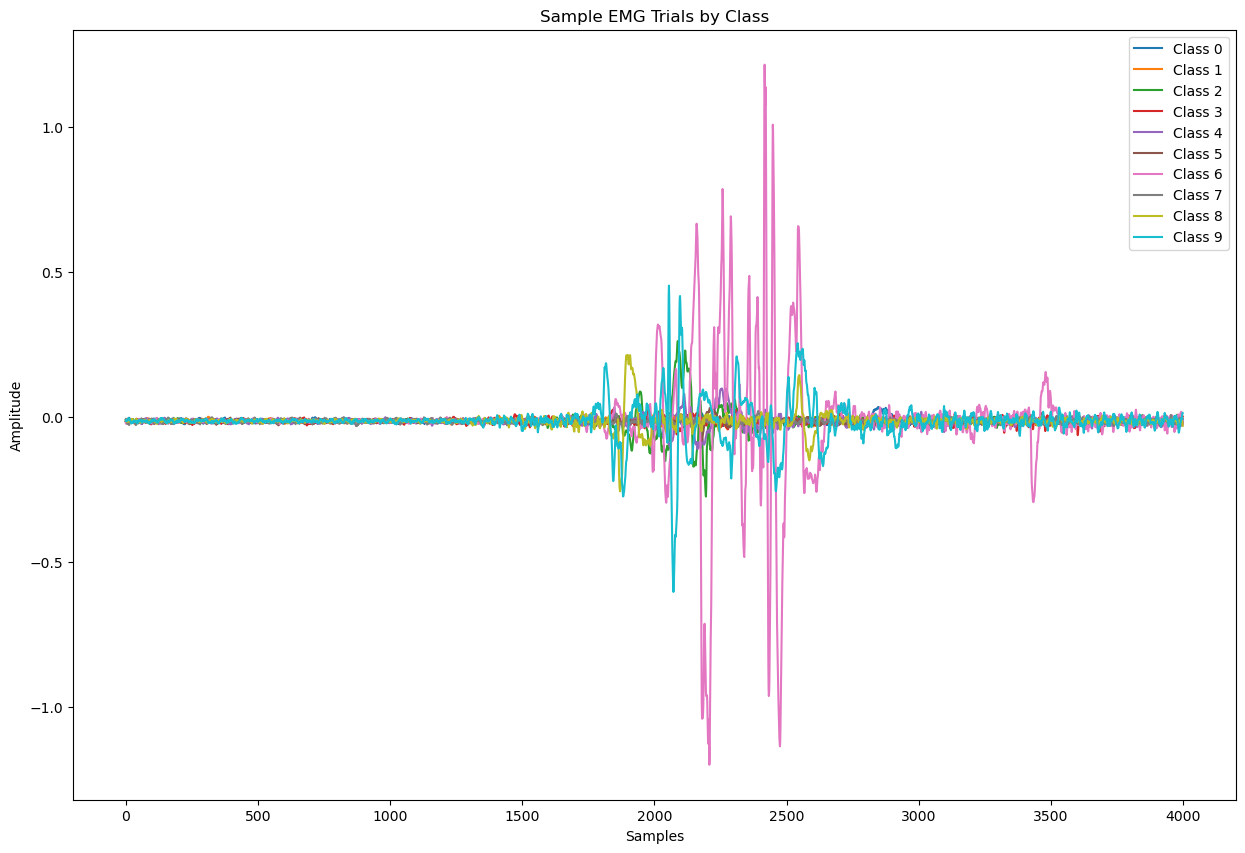

In [2]:
# Load data
data = pd.read_csv('emg_channel0_with_labels.csv')
X = data.iloc[:, :-1].values  # (360, 4000)
y = data.iloc[:, -1].values   # (360,)

# Verify balanced classes
print("Class distribution verification:")
print(pd.Series(y).value_counts().sort_index())

# Plot sample EMG trials
plt.figure(figsize=(15, 10))
for i in range(10):  # Plot one trial per class
    class_samples = np.where(y == i)[0]
    plt.plot(X[class_samples[0]], label=f'Class {i}')
plt.title("Sample EMG Trials by Class")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [4]:
# Normalize each trial independently while preserving temporal structure
def normalize_trial(trial):
    return (trial - np.mean(trial)) / (np.std(trial) + 1e-8)  # Small epsilon to avoid division by zero

X_normalized = np.array([normalize_trial(trial) for trial in X])

# Create train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Verify split maintained class balance
print("\nTrain class distribution:", np.bincount(y_train.astype(int)))
print("Test class distribution:", np.bincount(y_test.astype(int)))


Train class distribution: [29 29 29 28 29 29 28 29 29 29]
Test class distribution: [7 7 7 8 7 7 8 7 7 7]


Train & evaluate models

In [5]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, 
                                          max_depth=None,
                                          random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', 
                    C=10, 
                    gamma='scale',
                    random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200,
                            max_depth=6,
                            learning_rate=0.1,
                            objective='multi:softmax',
                            num_class=10,
                            random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5,
                                weights='distance'),
    "LDA": LinearDiscriminantAnalysis()
}

In [6]:
# Evaluation function with cross-validation
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Final training and testing
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    # Metrics
    metrics = {
        'Model': model_name,
        'CV Accuracy (Mean)': np.mean(cv_scores),
        'CV Accuracy (Std)': np.std(cv_scores),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test F1 (Macro)': f1_score(y_test, y_pred, average='macro'),
        'Training Time (s)': train_time
    }
    return metrics

In [7]:
# Evaluate all models
results = {}
for name, model in models.items():
    results[name] = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    
    # Print results
    print(f"\n=== {name} ===")
    print(f"CV Accuracy: {results[name]['CV Accuracy (Mean)']:.3f} ± {results[name]['CV Accuracy (Std)']:.3f}")
    print(f"Test Accuracy: {results[name]['Test Accuracy']:.3f}")
    print(f"Test F1 (Macro): {results[name]['Test F1 (Macro)']:.3f}")
    print(f"Training Time: {results[name]['Training Time (s)']:.2f}s")
    


=== Random Forest ===
CV Accuracy: 0.292 ± 0.034
Test Accuracy: 0.292
Test F1 (Macro): 0.264
Training Time: 3.64s

=== SVM (RBF) ===
CV Accuracy: 0.191 ± 0.037
Test Accuracy: 0.208
Test F1 (Macro): 0.197
Training Time: 0.15s

=== XGBoost ===
CV Accuracy: 0.219 ± 0.027
Test Accuracy: 0.236
Test F1 (Macro): 0.224
Training Time: 85.39s

=== k-NN ===
CV Accuracy: 0.205 ± 0.035
Test Accuracy: 0.194
Test F1 (Macro): 0.177
Training Time: 0.01s

=== LDA ===
CV Accuracy: 0.094 ± 0.039
Test Accuracy: 0.111
Test F1 (Macro): 0.083
Training Time: 0.21s


Model Performance Comparison

In [8]:
# Create comparison table
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df[['CV Accuracy (Mean)', 'CV Accuracy (Std)', 
                        'Test Accuracy', 'Test F1 (Macro)', 'Training Time (s)']]
print("\n=== Model Performance Comparison ===")
print(results_df.sort_values('Test Accuracy', ascending=False))


=== Model Performance Comparison ===
               CV Accuracy (Mean)  CV Accuracy (Std)  Test Accuracy  \
Random Forest            0.291531           0.034411       0.291667   
XGBoost                  0.218633           0.027283       0.236111   
SVM (RBF)                0.190744           0.036848       0.208333   
k-NN                     0.204779           0.035220       0.194444   
LDA                      0.093587           0.038898       0.111111   

               Test F1 (Macro)  Training Time (s)  
Random Forest         0.264035           3.636899  
XGBoost               0.224127          85.385701  
SVM (RBF)             0.197156           0.154495  
k-NN                  0.177100           0.005053  
LDA                   0.083333           0.208374  


Deep learning methods approach

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM
from tensorflow.keras.utils import to_categorical

# Prepare data for deep learning models
# Reshape: (samples, timesteps, 1)
X_train_dl = X_train[..., np.newaxis]
X_test_dl = X_test[..., np.newaxis]

# Convert labels to categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


In [12]:
# CNN model
cnn = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(X_train_dl.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train CNN
# Final training and testing
start_time = time.time()
cnn.fit(X_train_dl, y_train_cat, epochs=30, batch_size=32, verbose=0, validation_split=0.2)
train_time = time.time() - start_time

cnn_test_loss, cnn_test_acc = cnn.evaluate(X_test_dl, y_test_cat, verbose=0)

print(f"\n=== CNN ===")
print(f"Test Accuracy: {cnn_test_acc:.4f}")
print(f"Test Loss: {cnn_test_loss:.4f}")
print(f"Training Time: {train_time:.2f}s")


=== CNN ===
Test Accuracy: 0.3333
Test Loss: 3.1206
Training Time: 36.05s


In [16]:
# LSTM model
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_dl.shape[1], 1)),
    LSTM(32),
    Dense(10, activation='softmax')
])
lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train LSTM
start_time = time.time()
lstm.fit(X_train_dl, y_train_cat, epochs=30, batch_size=32, verbose=0, validation_split=0.2)
train_time = time.time() - start_time

lstm_test_loss, lstm_test_acc = lstm.evaluate(X_test_dl, y_test_cat, verbose=0)

print(f"\n=== LSTM ===")
print(f"Test Accuracy: {lstm_test_acc:.4f}")
print(f"Test Loss: {lstm_test_loss:.4f}")
print(f"Training Time: {train_time:.2f}s")

c:\Users\maria\anaconda3\envs\ift6758-conda-env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



=== LSTM ===
Test Accuracy: 0.1389
Test Loss: 2.2472
Training Time: 548.78s


In [15]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', models["Random Forest"]),
        ('xgb', models["XGBoost"]),
        ('svm', models["SVM (RBF)"])
    ],
    voting='hard'
)

ensemble_results = evaluate_model(ensemble, X_train, y_train, X_test, y_test, "Ensemble")
print(ensemble_results)

{'Model': 'Ensemble', 'CV Accuracy (Mean)': np.float64(0.2637628554143981), 'CV Accuracy (Std)': np.float64(0.04246461998732248), 'Test Accuracy': 0.2916666666666667, 'Test F1 (Macro)': 0.26910585286746275, 'Training Time (s)': 81.55912017822266}
